# Wine Quality Prediction

## Project Overview

This project focuses on predicting wine quality using machine learning classification techniques.

The dataset contains physicochemical properties of wine, such as acidity, residual sugar, chlorides, density, pH, sulphates and alcohol. These properties are analyzed to understand their relationship with wine quality.

## Objectives

- Perform Exploratory Data Analysis (EDA)
- Inspect and clean the dataset
- Analyze the distribution of wine quality
- Study relationships between physicochemical properties
- Prepare the data for machine learning
- Build classification models
- Evaluate and compare model performance
- Identify important factors associated with wine quality

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [24]:
file_path = "../dataset/winequality-red.csv"

df = pd.read_csv(file_path, sep=",")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

Dataset loaded successfully!
Shape: (1599, 12)
Columns:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


In [25]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [26]:
df.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5
1598,6.0,0.310,0.47,3.6,0.067,18.0,42.0,0.99549,3.39,0.66,11.0,6


In [27]:
print(df.shape)
print(df.columns.tolist())

(1599, 12)
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


In [28]:
# Initial inspection of the dataset

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nDescriptive Statistics:")
display(df.describe())

Dataset Shape: (1599, 12)

Column Names:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [29]:
print("Wine Quality Distribution:")
print(df['quality'].value_counts().sort_index())

Wine Quality Distribution:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


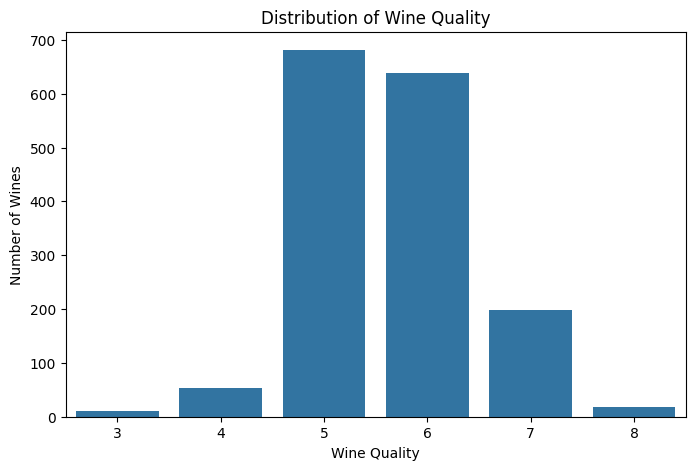

In [30]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='quality')

plt.title('Distribution of Wine Quality')
plt.xlabel('Wine Quality')
plt.ylabel('Number of Wines')

plt.show()

In [31]:
print("Quality Statistics:")
print(df['quality'].describe())

Quality Statistics:
count    1599.000000
mean        5.636023
std         0.807569
min         3.000000
25%         5.000000
50%         6.000000
75%         6.000000
max         8.000000
Name: quality, dtype: float64


In [32]:
quality_counts = df['quality'].value_counts().sort_index()

quality_percentage = (
    df['quality'].value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

quality_distribution = pd.DataFrame({
    'Count': quality_counts,
    'Percentage': quality_percentage
})

display(quality_distribution)

,Count,Percentage
quality,,
3,10,0.63
4,53,3.31
5,681,42.59
6,638,39.90
7,199,12.45
8,18,1.13


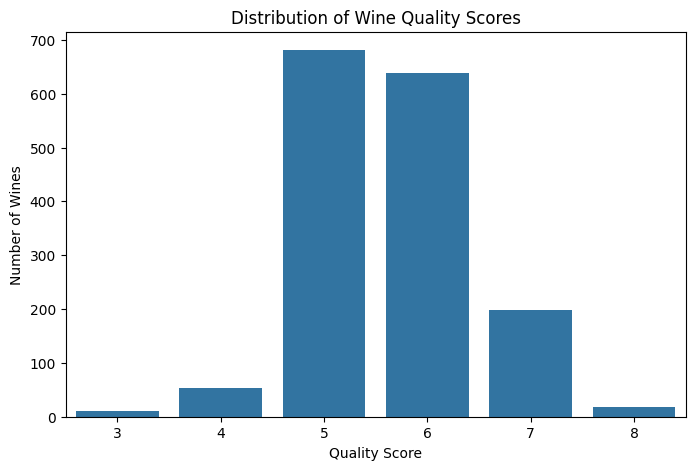

In [33]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='quality')

plt.title('Distribution of Wine Quality Scores')
plt.xlabel('Quality Score')
plt.ylabel('Number of Wines')

plt.show()

## Observation

The quality scores are not evenly distributed across the dataset. Some quality categories contain considerably more wine samples than others. This class distribution is important to consider while building and evaluating classification models.

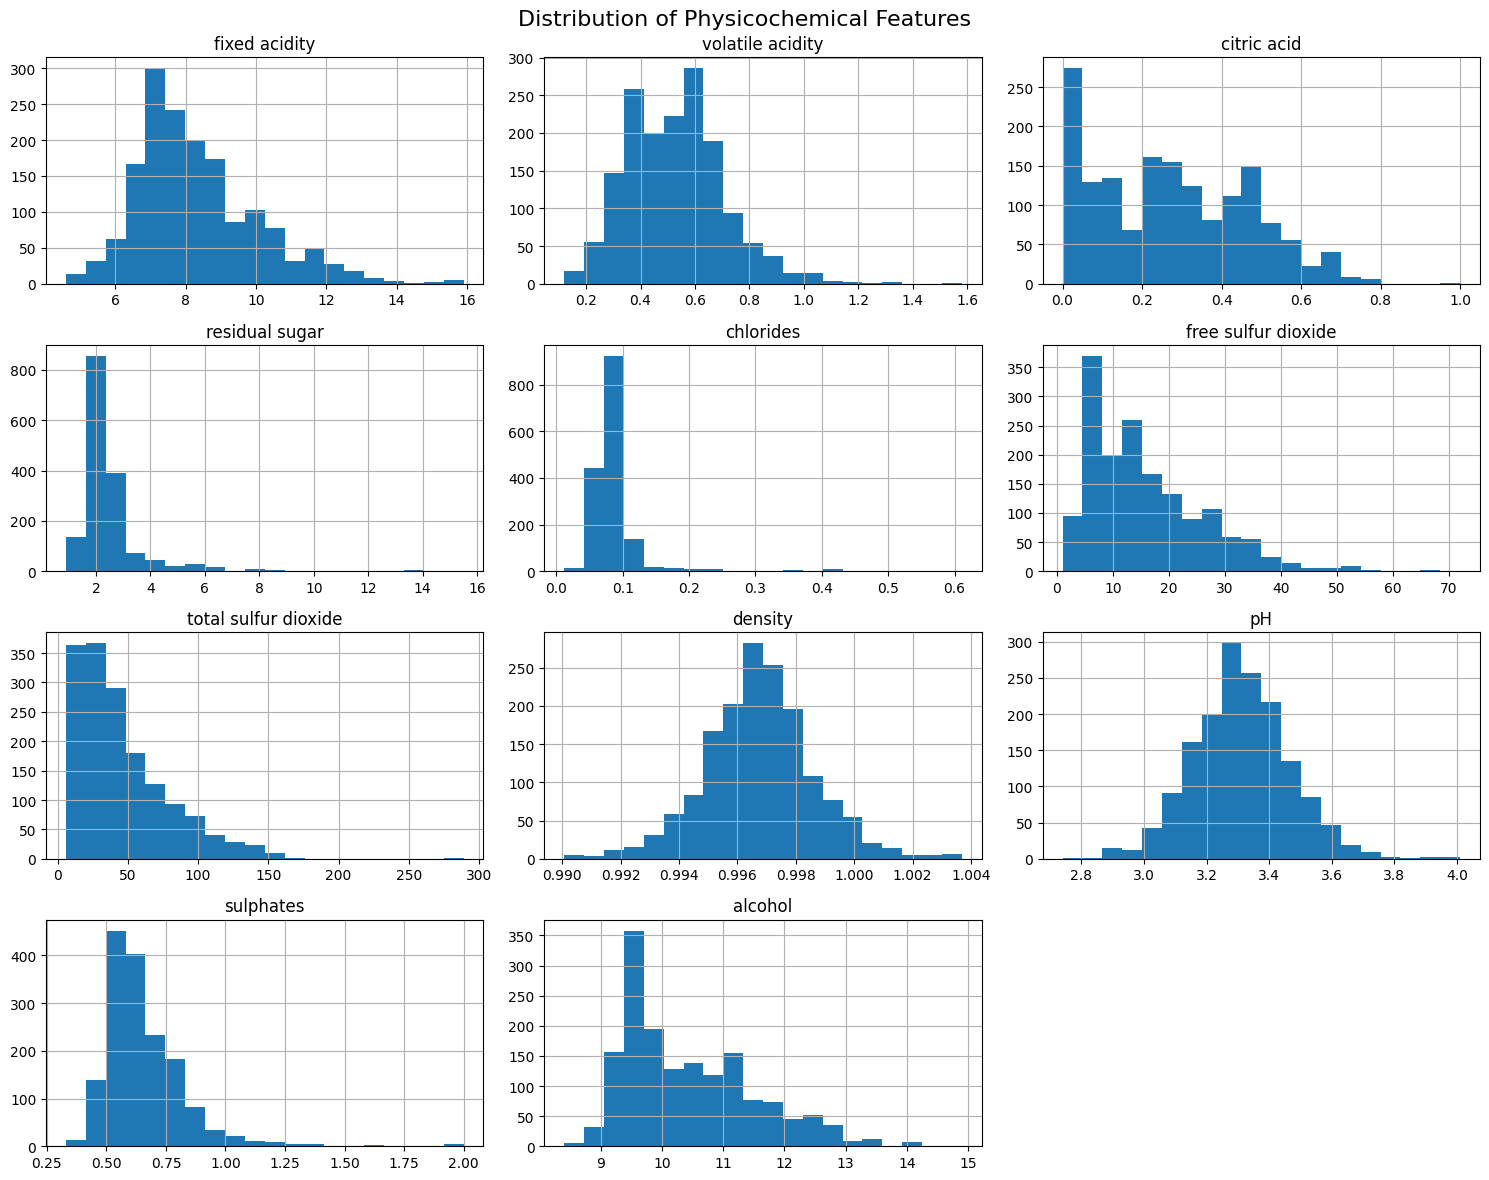

In [34]:
# Plot distributions of all physicochemical features

features = df.columns.drop('quality')

df[features].hist(
    figsize=(15, 12),
    bins=20
)

plt.suptitle('Distribution of Physicochemical Features', fontsize=16)
plt.tight_layout()
plt.show()

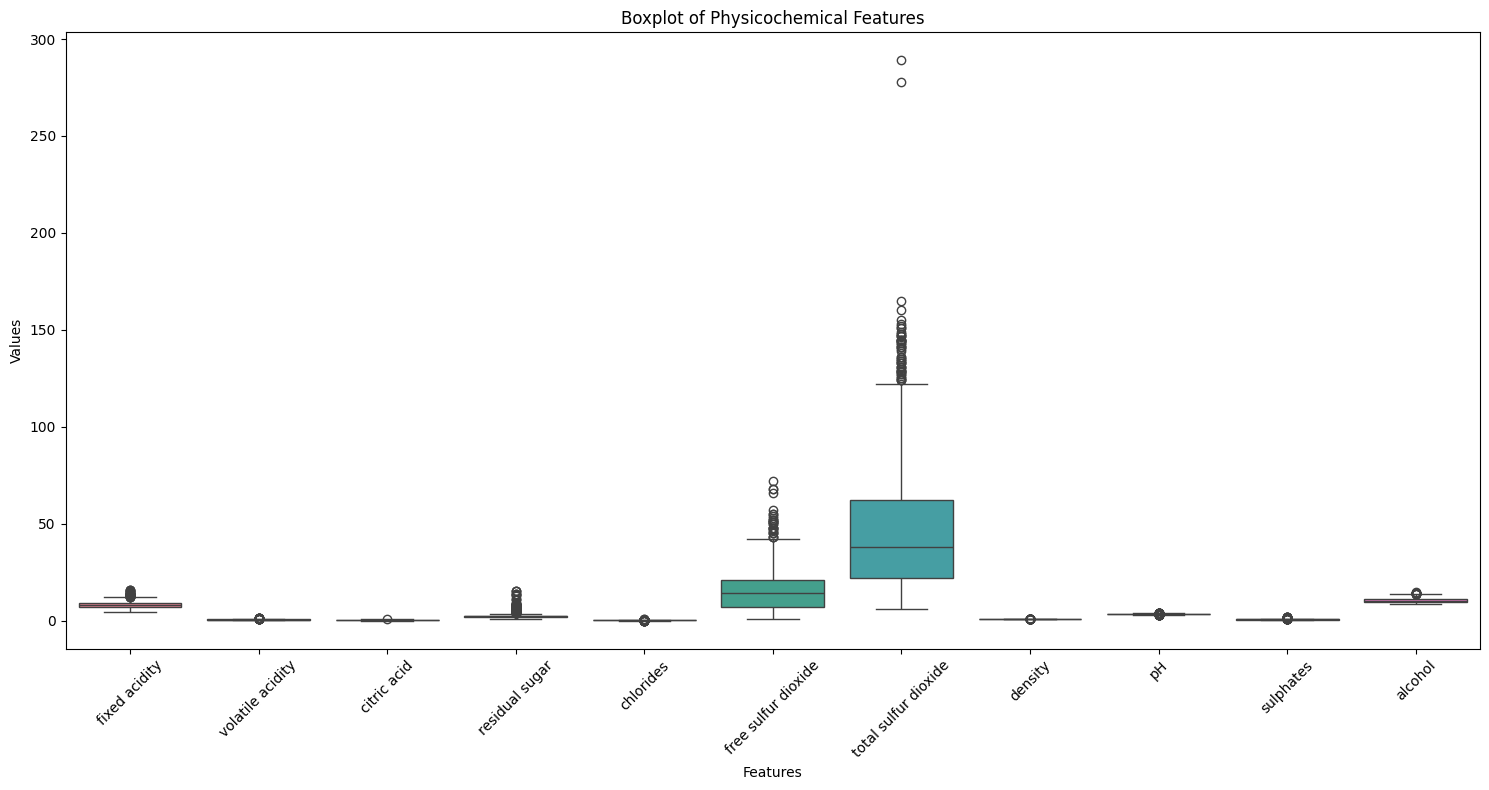

In [35]:
plt.figure(figsize=(15, 8))

sns.boxplot(data=df[features])

plt.title('Boxplot of Physicochemical Features')
plt.xlabel('Features')
plt.ylabel('Values')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [36]:
feature_summary = df[features].describe().T

display(feature_summary)

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


## Feature Distribution and Outlier Observation

The physicochemical features show different ranges and distributions. Some variables contain skewed distributions, while the boxplots indicate the presence of potential outliers in several chemical properties.

These differences in feature scale are important during machine learning model preparation. Feature scaling will therefore be considered before applying models that are sensitive to the magnitude of input features.

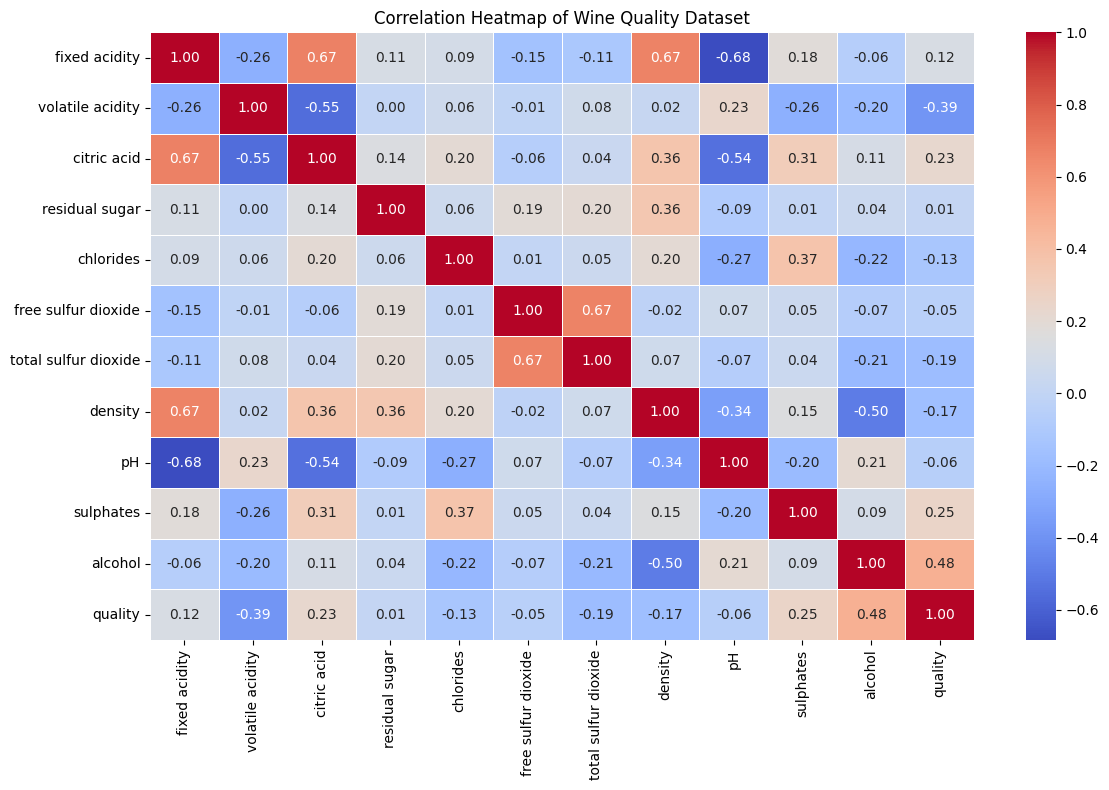

In [37]:
plt.figure(figsize=(12, 8))

correlation_matrix = df.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title('Correlation Heatmap of Wine Quality Dataset')
plt.tight_layout()
plt.show()

In [38]:
quality_correlation = (
    df.corr()['quality']
    .sort_values(ascending=False)
)

display(quality_correlation)

quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64

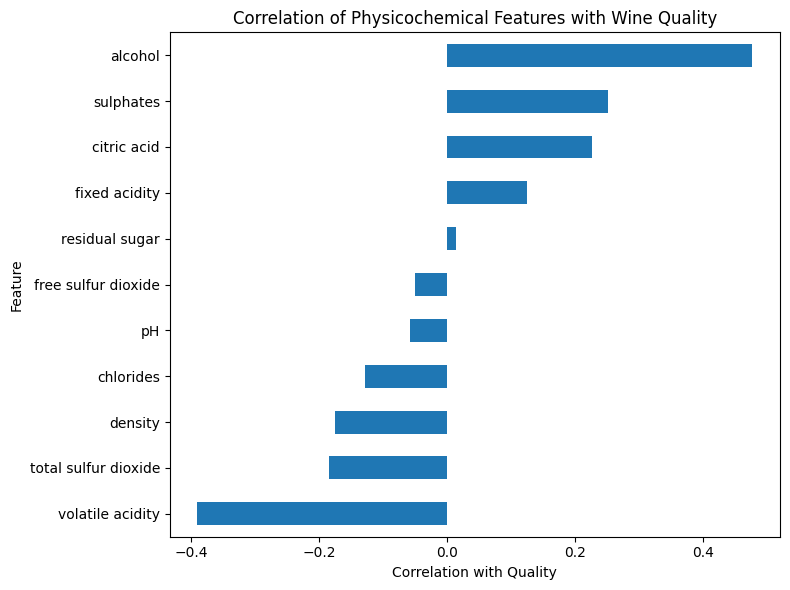

In [39]:
plt.figure(figsize=(8, 6))

quality_correlation.drop('quality').sort_values().plot(
    kind='barh',
    figsize=(8, 6)
)

plt.title('Correlation of Physicochemical Features with Wine Quality')
plt.xlabel('Correlation with Quality')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

## Correlation Analysis

The correlation analysis shows the strength and direction of the relationship between the physicochemical properties and wine quality.

Positive correlation indicates that higher values of a feature are associated with higher quality scores, while negative correlation indicates an inverse relationship.

The correlation matrix also helps identify relationships between independent features and can provide useful information for feature selection before model training.

In [40]:
# Separate features and target variable

X = df.drop('quality', axis=1)
y = df['quality']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1599, 11)
Target shape: (1599,)


In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1279, 11)
Testing data: (320, 11)


In [45]:
from sklearn.preprocessing import StandardScaler

In [46]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [48]:
# Create Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [49]:
# Predict wine quality on test data

y_pred_rf = rf_model.predict(X_test)

print("Predictions completed!")

Predictions completed!


In [50]:
# Calculate evaluation metrics

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, average='weighted', zero_division=0)
rf_recall = recall_score(y_test, y_pred_rf, average='weighted', zero_division=0)
rf_f1 = f1_score(y_test, y_pred_rf, average='weighted', zero_division=0)

print("Random Forest Performance")
print("-------------------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))

Random Forest Performance
-------------------------
Accuracy : 0.6781
Precision: 0.6531
Recall   : 0.6781
F1 Score : 0.6632


In [51]:
print("Random Forest Classification Report:")
print(classification_report(
    y_test,
    y_pred_rf,
    zero_division=0
))

Random Forest Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.71      0.76      0.73       136
           6       0.65      0.70      0.67       128
           7       0.71      0.55      0.62        40
           8       0.50      0.33      0.40         3

    accuracy                           0.68       320
   macro avg       0.43      0.39      0.40       320
weighted avg       0.65      0.68      0.66       320



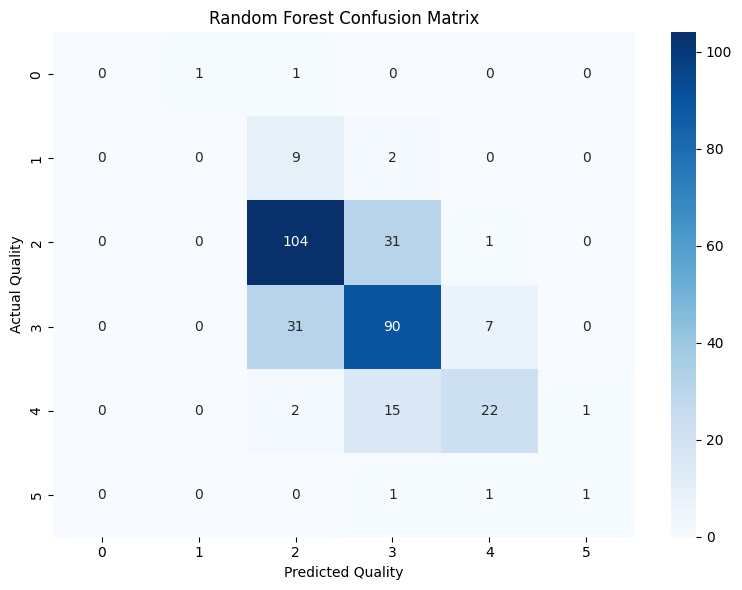

In [52]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Quality')
plt.ylabel('Actual Quality')

plt.tight_layout()
plt.show()

## Random Forest Model

A Random Forest Classifier was trained using the physicochemical properties of red wine. The model combines multiple decision trees to make predictions and can capture non-linear relationships between the input features and wine quality.

The model was evaluated using accuracy, precision, recall, F1-score, classification report, and a confusion matrix.

In [53]:
# Create SGD Classifier

sgd_model = SGDClassifier(
    random_state=42,
    max_iter=1000,
    tol=1e-3
)

# Train the model
sgd_model.fit(X_train_scaled, y_train)

print("SGD Classifier trained successfully!")

SGD Classifier trained successfully!


In [54]:
# Predict wine quality

y_pred_sgd = sgd_model.predict(X_test_scaled)

print("Predictions completed!")

Predictions completed!


In [55]:
sgd_accuracy = accuracy_score(y_test, y_pred_sgd)
sgd_precision = precision_score(
    y_test, y_pred_sgd,
    average='weighted',
    zero_division=0
)
sgd_recall = recall_score(
    y_test, y_pred_sgd,
    average='weighted',
    zero_division=0
)
sgd_f1 = f1_score(
    y_test, y_pred_sgd,
    average='weighted',
    zero_division=0
)

print("SGD Classifier Performance")
print("--------------------------")
print("Accuracy :", round(sgd_accuracy, 4))
print("Precision:", round(sgd_precision, 4))
print("Recall   :", round(sgd_recall, 4))
print("F1 Score :", round(sgd_f1, 4))

SGD Classifier Performance
--------------------------
Accuracy : 0.5125
Precision: 0.4991
Recall   : 0.5125
F1 Score : 0.4837


In [56]:
print("SGD Classification Report:")
print(classification_report(
    y_test,
    y_pred_sgd,
    zero_division=0
))

SGD Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.57      0.76      0.66       136
           6       0.51      0.28      0.36       128
           7       0.39      0.60      0.48        40
           8       0.00      0.00      0.00         3

    accuracy                           0.51       320
   macro avg       0.25      0.27      0.25       320
weighted avg       0.50      0.51      0.48       320



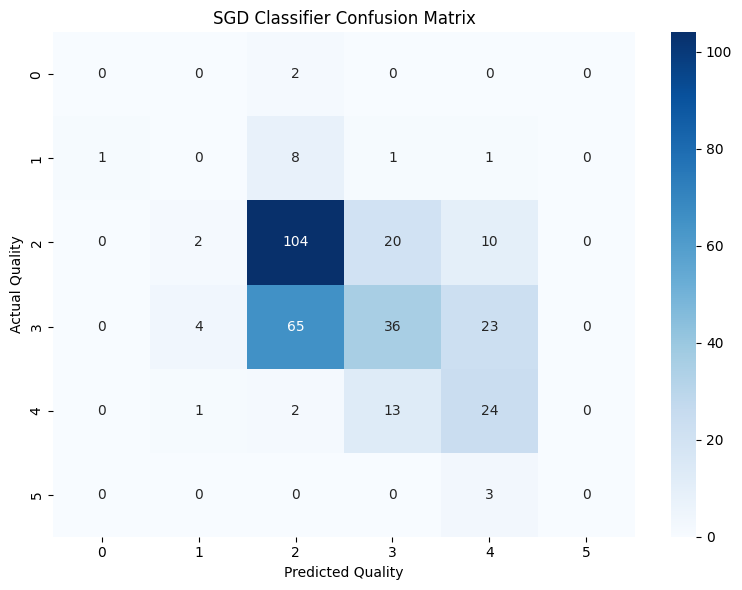

In [57]:
cm_sgd = confusion_matrix(y_test, y_pred_sgd)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_sgd,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('SGD Classifier Confusion Matrix')
plt.xlabel('Predicted Quality')
plt.ylabel('Actual Quality')

plt.tight_layout()
plt.show()

## SGD Classifier Model

The SGD Classifier was trained using standardized physicochemical features. Standardization was applied because SGD-based models are sensitive to differences in feature scales.

The model was evaluated using accuracy, precision, recall, F1-score, classification report, and confusion matrix.

In [58]:
# Create SVM model

svm_model = SVC(
    kernel='rbf',
    random_state=42
)

# Train the model
svm_model.fit(X_train_scaled, y_train)

print("SVM Classifier trained successfully!")

SVM Classifier trained successfully!


In [59]:
# Predict wine quality

y_pred_svm = svm_model.predict(X_test_scaled)

print("Predictions completed!")

Predictions completed!


In [60]:
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(
    y_test, y_pred_svm,
    average='weighted',
    zero_division=0
)
svm_recall = recall_score(
    y_test, y_pred_svm,
    average='weighted',
    zero_division=0
)
svm_f1 = f1_score(
    y_test, y_pred_svm,
    average='weighted',
    zero_division=0
)

print("SVM Classifier Performance")
print("--------------------------")
print("Accuracy :", round(svm_accuracy, 4))
print("Precision:", round(svm_precision, 4))
print("Recall   :", round(svm_recall, 4))
print("F1 Score :", round(svm_f1, 4))

SVM Classifier Performance
--------------------------
Accuracy : 0.625
Precision: 0.6048
Recall   : 0.625
F1 Score : 0.6023


In [61]:
print("SVM Classification Report:")
print(classification_report(
    y_test,
    y_pred_svm,
    zero_division=0
))

SVM Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.65      0.76      0.70       136
           6       0.58      0.65      0.61       128
           7       0.78      0.35      0.48        40
           8       0.00      0.00      0.00         3

    accuracy                           0.62       320
   macro avg       0.33      0.29      0.30       320
weighted avg       0.60      0.62      0.60       320



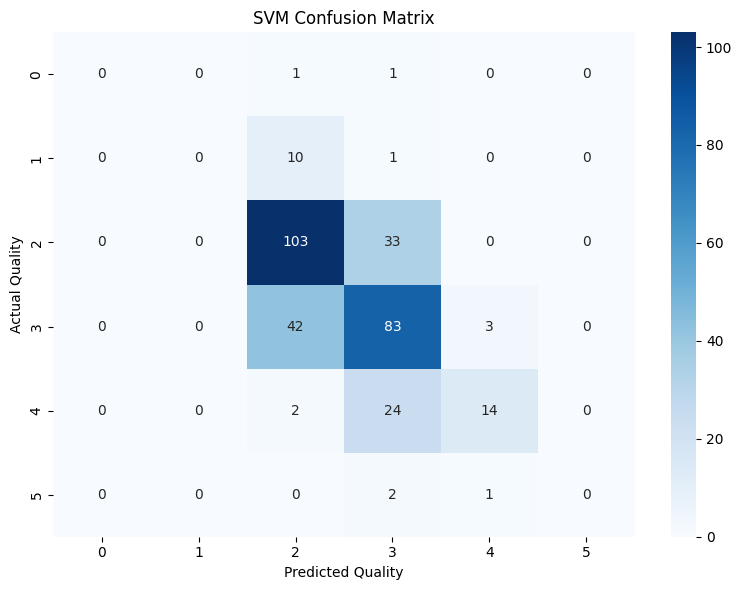

In [62]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted Quality')
plt.ylabel('Actual Quality')

plt.tight_layout()
plt.show()

## SVM Classifier Model

A Support Vector Machine classifier with an RBF kernel was trained using standardized physicochemical features.

The model was evaluated using accuracy, precision, recall, F1-score, classification report, and confusion matrix. The results will be compared with the Random Forest and SGD classifiers.

In [63]:
model_comparison = pd.DataFrame({
    'Model': [
        'Random Forest',
        'SGD Classifier',
        'SVM'
    ],
    'Accuracy': [
        rf_accuracy,
        sgd_accuracy,
        svm_accuracy
    ],
    'Precision': [
        rf_precision,
        sgd_precision,
        svm_precision
    ],
    'Recall': [
        rf_recall,
        sgd_recall,
        svm_recall
    ],
    'F1 Score': [
        rf_f1,
        sgd_f1,
        svm_f1
    ]
})

display(model_comparison.round(4))

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.6781,0.6531,0.6781,0.6632
1,SGD Classifier,0.5125,0.4991,0.5125,0.4837
2,SVM,0.6250,0.6048,0.6250,0.6023


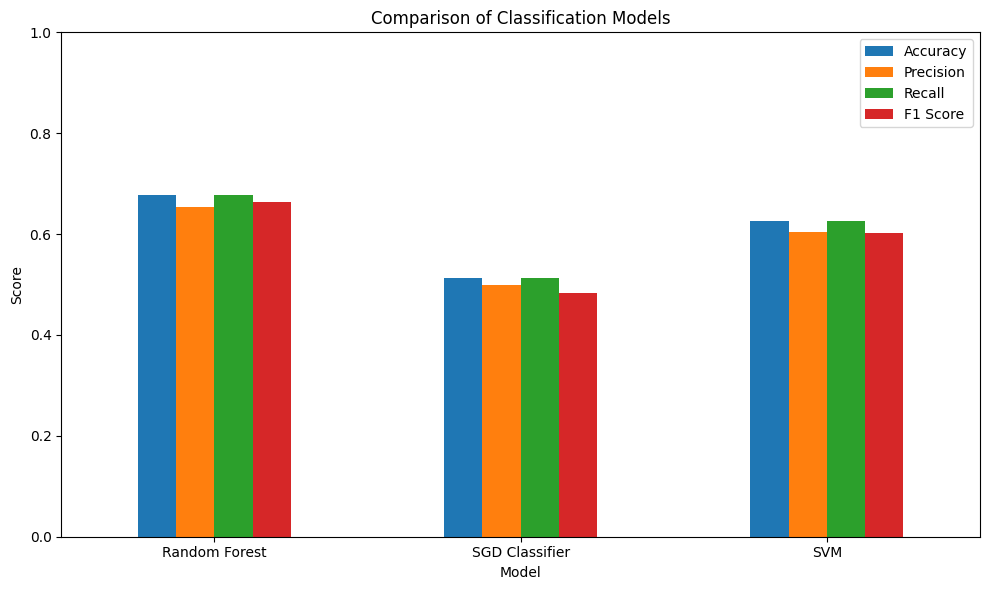

In [64]:
model_comparison.set_index('Model')[[
    'Accuracy',
    'Precision',
    'Recall',
    'F1 Score'
]].plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Comparison of Classification Models')
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [65]:
model_comparison.to_csv(
    "../output/model_comparison.csv",
    index=False
)

print("Model comparison saved successfully!")

Model comparison saved successfully!


## Model Comparison

Three classification models were evaluated for wine quality prediction: Random Forest, SGD Classifier, and Support Vector Machine (SVM).

The models were compared using accuracy, precision, recall, and F1-score. These metrics provide a broader evaluation of classification performance, especially because the wine quality classes are not evenly distributed.

The comparison results are stored in `model_comparison.csv`.

In [66]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

display(feature_importance)

,Feature,Importance
10,alcohol,0.152106
9,sulphates,0.112057
1,volatile acidity,0.103678
6,total sulfur dioxide,0.101487
7,density,0.088812
4,chlorides,0.079941
8,pH,0.079460
0,fixed acidity,0.076209
3,residual sugar,0.073386
2,citric acid,0.068562


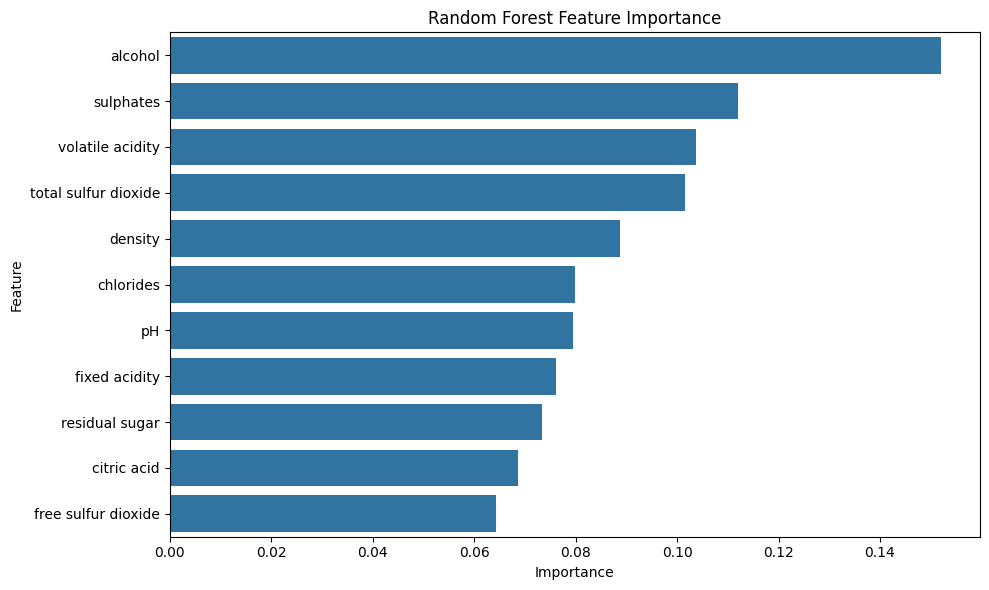

In [67]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

In [68]:
feature_importance.to_csv(
    "../output/feature_importance.csv",
    index=False
)

print("Feature importance saved successfully!")

Feature importance saved successfully!


## Feature Importance Analysis

Random Forest feature importance was used to examine the relative contribution of each physicochemical feature to wine quality prediction.

The feature importance values indicate how much each feature contributes to the decision-making process of the Random Forest model. Features with higher importance values have a greater contribution to the model's predictions.

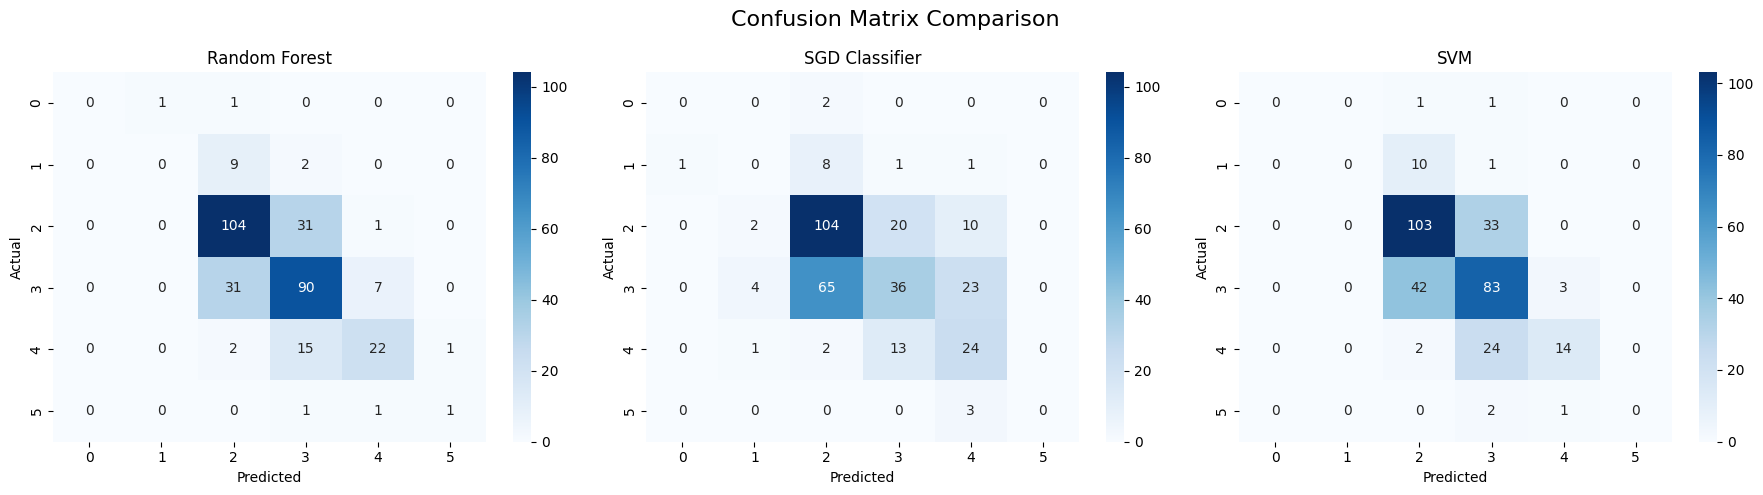

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Random Forest
sns.heatmap(
    confusion_matrix(y_test, y_pred_rf),
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0]
)
axes[0].set_title('Random Forest')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# SGD
sns.heatmap(
    confusion_matrix(y_test, y_pred_sgd),
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[1]
)
axes[1].set_title('SGD Classifier')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# SVM
sns.heatmap(
    confusion_matrix(y_test, y_pred_svm),
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[2]
)
axes[2].set_title('SVM')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.suptitle('Confusion Matrix Comparison', fontsize=16)
plt.tight_layout()
plt.show()

In [70]:
print("Random Forest Classification Report")
print(classification_report(y_test, y_pred_rf, zero_division=0))

print("\nSGD Classification Report")
print(classification_report(y_test, y_pred_sgd, zero_division=0))

print("\nSVM Classification Report")
print(classification_report(y_test, y_pred_svm, zero_division=0))

Random Forest Classification Report
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.71      0.76      0.73       136
           6       0.65      0.70      0.67       128
           7       0.71      0.55      0.62        40
           8       0.50      0.33      0.40         3

    accuracy                           0.68       320
   macro avg       0.43      0.39      0.40       320
weighted avg       0.65      0.68      0.66       320


SGD Classification Report
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.57      0.76      0.66       136
           6       0.51      0.28      0.36       128
           7       0.39      0.60      0.48        40
           8       0.00      0.00      0.00         3

    accuracy  

In [71]:
final_results = model_comparison.copy()

final_results[['Accuracy', 'Precision', 'Recall', 'F1 Score']] = (
    final_results[['Accuracy', 'Precision', 'Recall', 'F1 Score']]
    .round(4)
)

display(final_results)

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.6781,0.6531,0.6781,0.6632
1,SGD Classifier,0.5125,0.4991,0.5125,0.4837
2,SVM,0.6250,0.6048,0.6250,0.6023


## Detailed Model Evaluation

The classification models were evaluated using confusion matrices and class-level precision, recall, and F1-scores.

The confusion matrices provide a visual representation of correct and incorrect predictions for each wine quality class. Class-level evaluation is particularly useful because the quality categories are not evenly distributed.

The final evaluation table summarizes the performance of all three classification models.

In [72]:
quality_corr = (
    df.corr()['quality']
    .drop('quality')
    .sort_values(ascending=False)
)

print("Features positively correlated with quality:")
display(quality_corr[quality_corr > 0])

print("\nFeatures negatively correlated with quality:")
display(quality_corr[quality_corr < 0])

Features positively correlated with quality:


alcohol           0.476166
sulphates         0.251397
citric acid       0.226373
fixed acidity     0.124052
residual sugar    0.013732
Name: quality, dtype: float64


Features negatively correlated with quality:


free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64

In [73]:
print("Top 5 Important Features:")
display(feature_importance.head(5))

Top 5 Important Features:


,Feature,Importance
10,alcohol,0.152106
9,sulphates,0.112057
1,volatile acidity,0.103678
6,total sulfur dioxide,0.101487
7,density,0.088812


In [74]:
top_features = feature_importance.head(5).copy()

top_features['Importance'] = top_features['Importance'].round(4)

display(top_features)

,Feature,Importance
10,alcohol,0.1521
9,sulphates,0.1121
1,volatile acidity,0.1037
6,total sulfur dioxide,0.1015
7,density,0.0888


## Key Insights

Based on the exploratory analysis and machine learning results, the following insights were obtained:

1. Wine quality scores are unevenly distributed across the dataset, with some quality categories containing substantially more samples than others.

2. The physicochemical properties of wine show different distributions and ranges, with potential outliers present in several variables.

3. Correlation analysis provides an understanding of the relationship between chemical properties and wine quality.

4. Random Forest feature importance helps identify the physicochemical properties that contribute most to the model's predictions.

5. The three classification models — Random Forest, SGD Classifier, and SVM — provide different levels of predictive performance and demonstrate how model choice can affect wine quality prediction.

6. The results show that physicochemical measurements can be used as useful inputs for machine learning-based wine quality classification.

# Conclusion

This project analyzed the physicochemical properties of red wine and developed machine learning classification models to predict wine quality.

Exploratory Data Analysis was performed to understand the dataset, quality distribution, feature distributions, correlations, and potential outliers.

Three classification algorithms were implemented:

- Random Forest Classifier
- SGD Classifier
- Support Vector Machine (SVM)

The models were evaluated using accuracy, precision, recall, F1-score, classification reports, and confusion matrices.

Random Forest feature importance was also analyzed to understand which physicochemical properties contributed most to the model's predictions.

Overall, the project demonstrates how exploratory data analysis, feature preprocessing, machine learning, and model evaluation can be combined to build a wine quality prediction system.

In [75]:
df.to_csv(
    "../output/winequality_processed.csv",
    index=False
)

print("Processed dataset saved successfully!")

Processed dataset saved successfully!
